In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import warnings
import random
import os
from tqdm import tqdm
warnings.filterwarnings("ignore")

In [2]:
# Check for GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
# Check for TPU (using PyTorch/XLA)
elif 'TPU_ACCELERATOR_TYPE' in os.environ or 'COLAB_TPU_1vm' in os.environ:
    import torch_xla
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
else:
    # Fallback to CPU
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [ ]:
# ----------------------------
# Load Data
# ----------------------------
df = pd.read_csv("data.csv", header=0, index_col=0)
y_full = df.iloc[:, 0].values.astype(np.int64)     # label: 0 or 1
X_full = df.iloc[:, 1:].values.astype(np.float32)  # (N, 1033)

print(f"Loaded {X_full.shape[0]} users, time-series length = {X_full.shape[1]}")
print(f"Theft ratio: {y_full.mean():.3f} ({(y_full == 1).sum()} theft / {(y_full == 0).sum()} normal)")


Loaded 42372 users, time-series length = 1034
Theft ratio: 0.085 (3615 theft / 38757 normal)


In [4]:
def interpolate_missing(data):
    """Linear interpolation for NaN values."""
    df = pd.DataFrame(data)
    df = df.replace(0, np.nan)  # assuming 0 may indicate missing (adjust if needed)
    df = df.interpolate(method='linear', limit_direction='both')
    return df.values

def normalize_data(data):
    scaler = MinMaxScaler()
    return scaler.fit_transform(data.T).T, scaler  # normalize each user series independently

In [5]:
def interpolate_missing_paper(X):
    """
    Vectorized implementation of Eq. (18) from the paper.
    X: (N, L) array of time-series data
    Returns: interpolated X, same shape
    """
    X = X.copy()
    # Treat 0 and NaN as missing
    missing = (X == 0) | np.isnan(X)

    # Create shifted views (pad with invalid values at edges)
    left = np.roll(X, 1, axis=1)
    right = np.roll(X, -1, axis=1)

    # Mark edges as invalid (no two neighbors)
    left[:, 0] = 0      # first column has no left neighbor
    right[:, -1] = 0    # last column has no right neighbor

    # Check if neighbors are valid (not missing and not zero)
    left_valid = ~((left == 0) | np.isnan(left))
    right_valid = ~((right == 0) | np.isnan(right))

    # Apply Eq. (18): only fill if both neighbors are valid
    fill_mask = missing & left_valid & right_valid
    X[fill_mask] = (left[fill_mask] + right[fill_mask]) / 2.0

    # Set all remaining missing values to 0
    X[missing & ~fill_mask] = 0.0

    return X

In [ ]:
# ----------------------------
# Preprocessing
# ----------------------------
def interpolate_missing(data):
    """Linear interpolation for NaN values."""
    df = pd.DataFrame(data)
    df = df.replace(0, np.nan)  # assuming 0 may indicate missing (adjust if needed)
    df = df.interpolate(method='linear', limit_direction='both')
    return df.values

# Apply interpolation
X_clean = interpolate_missing(X_full)
# X_clean = interpolate_missing_paper(X) # The paper's version of interpolation. This may be flawed

# Min-Max scaling per user (Eq. 19)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_clean)

In [ ]:
# ----------------------------
# Train/Val/Test Split (8:1:1, stratified)
# ----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_full, test_size=0.2, stratify=y_full, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

X_train_normal = X_train[y_train == 0]
X_train_theft  = X_train[y_train == 1]

print(f"Train: {len(X_train_normal)} normal, {len(X_train_theft)} theft")


Train: 31005 normal, 2892 theft


In [8]:
# ----------------------------
# VAE Encoder
# ----------------------------
input_dim = X_train.shape[1]  # 1033
latent_dim = 100

class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1)
        self.fc_mu = nn.Linear(256 * (input_dim // 8), latent_dim)
        self.fc_logvar = nn.Linear(256 * (input_dim // 8), latent_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


In [9]:
# ----------------------------
# GAN Generator / VAE Decoder
# ----------------------------

class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.output_dim = output_dim
        self.feature_map_size = output_dim // 8 + 1
        self.fc = nn.Linear(latent_dim, 256 * self.feature_map_size)
        self.deconv1 = nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1)
        self.deconv3 = nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1)
        self.deconv4 = nn.ConvTranspose1d(32, 1, kernel_size=4, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, z):
        x = self.relu(self.fc(z))
        x = x.view(-1, 256, self.feature_map_size)
        x = self.relu(self.deconv1(x))
        x = self.relu(self.deconv2(x))
        x = self.relu(self.deconv3(x))
        x = self.sigmoid(self.deconv4(x))
        x = x.squeeze(1)
        # Crop or pad to match output_dim
        if x.size(1) > self.output_dim:
            x = x[:, :self.output_dim]
        elif x.size(1) < self.output_dim:
            pad = self.output_dim - x.size(1)
            x = nn.functional.pad(x, (0, pad))
        return x


In [ ]:
# ----------------------------
# WGAN Critic (Discriminator)
# ----------------------------

class Critic(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)  # No sigmoid, output raw score
        )
    def forward(self, x):
        return self.model(x)


In [ ]:
# ----------------------------
# VAE-WGAN
# ----------------------------

class VAE_WGAN(nn.Module):
    def __init__(self, input_dim, latent_dim=100):
        super().__init__()
        self.encoder = Encoder(input_dim, latent_dim)
        self.generator = Generator(latent_dim, input_dim)
        self.critic = Critic(input_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.generator(z)
        return recon_x, mu, logvar


In [ ]:
# ----------------------------
# Improved VAE-WGAN Training Loop
# ----------------------------

def wasserstein_loss(real_scores, fake_scores):
    return torch.mean(fake_scores) - torch.mean(real_scores)

def gradient_penalty(critic, real_data, fake_data, device, lambda_gp=10):
    batch_size = real_data.size(0)
    epsilon = torch.rand(batch_size, 1).to(device)
    epsilon = epsilon.expand_as(real_data)
    interpolated = epsilon * real_data + (1 - epsilon) * fake_data
    interpolated.requires_grad_(True)
    scores = critic(interpolated)
    gradients = torch.autograd.grad(
        outputs=scores,
        inputs=interpolated,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    gradients = gradients.view(batch_size, -1)
    grad_norm = gradients.norm(2, dim=1)
    gp = lambda_gp * ((grad_norm - 1) ** 2).mean()
    return gp

theft_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_theft)),
    batch_size=100, shuffle=True
)

vae_wgan = VAE_WGAN(input_dim, latent_dim).to(device)

opt_enc = optim.Adam(vae_wgan.encoder.parameters(), lr=0.0004)
opt_gen = optim.Adam(vae_wgan.generator.parameters(), lr=0.0004)
opt_critic = optim.Adam(vae_wgan.critic.parameters(), lr=0.0004)

# Loss weights
recon_weight = 1.0
kld_weight = 0.01
wgan_weight = 1.0
lambda_gp = 10

def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss, kld

epochs_vae_wgan = 10000
critic_steps = 5  # Train critic more times per generator/encoder step


In [ ]:
for epoch in tqdm(range(epochs_vae_wgan), desc="VAE-WGAN Training"):
    vae_losses, critic_losses, gen_losses = [], [], []

    for batch in theft_loader:
        x_real = batch[0].to(device)
        batch_size = x_real.size(0)

        # =======================
        # (1) VAE Step: Recon + KL
        # =======================
        mu, logvar = vae_wgan.encoder(x_real)
        z = vae_wgan.reparameterize(mu, logvar)
        x_recon = vae_wgan.generator(z)
        recon_loss, kld = vae_loss(x_recon, x_real, mu, logvar)

        # ==================================
        # (2) Critic (WGAN) Step
        # ==================================
        for _ in range(critic_steps):
            z_rand = torch.randn(batch_size, latent_dim).to(device)
            x_fake = vae_wgan.generator(z_rand).detach()
            real_scores = vae_wgan.critic(x_real)
            fake_scores = vae_wgan.critic(x_fake)
            gp = gradient_penalty(vae_wgan.critic, x_real, x_fake, device, lambda_gp)
            loss_critic = wasserstein_loss(real_scores, fake_scores) + gp

            opt_critic.zero_grad()
            loss_critic.backward()
            opt_critic.step()

        # ==================================
        # (3) Generator (VAE + WGAN) Step
        # ==================================
        z_rand2 = torch.randn(batch_size, latent_dim).to(device)
        x_fake2 = vae_wgan.generator(z_rand2)
        fake_scores2 = vae_wgan.critic(x_fake2)
        loss_wgan = -torch.mean(fake_scores2)

        total_gen_loss = (
            recon_weight * recon_loss +
            kld_weight * kld +
            wgan_weight * loss_wgan
        )

        opt_enc.zero_grad()
        opt_gen.zero_grad()
        total_gen_loss.backward()
        opt_enc.step()
        opt_gen.step()

        # =======================
        # Logging
        # =======================
        vae_losses.append(recon_loss.item() + kld.item())
        critic_losses.append(loss_critic.item())
        gen_losses.append(loss_wgan.item())

    # =======================
    # Progress Print
    # =======================
    if epoch % 100 == 0:
        print(
            f"VAE-WGAN Epoch {epoch}: "
            f"VAE={np.mean(vae_losses):.4f}, "
            f"Critic={np.mean(critic_losses):.4f}, "
            f"Gen={np.mean(gen_losses):.4f}"
        )


In [ ]:
vae_wgan_save_path = "saved_models/vae_wgan.pth"
os.makedirs(os.path.dirname(vae_wgan_save_path), exist_ok=True)

# Save the entire VAE-WGAN state (model architecture + trained weights)
torch.save({
    'encoder_state_dict': vae_wgan.encoder.state_dict(),
    'generator_state_dict': vae_wgan.generator.state_dict(),
    'critic_state_dict': vae_wgan.critic.state_dict(),
    'opt_enc_state_dict': opt_enc.state_dict(),
    'opt_gen_state_dict': opt_gen.state_dict(),
    'opt_critic_state_dict': opt_critic.state_dict(),
    'epoch': epoch,
}, vae_wgan_save_path)

print(f"VAE-WGAN saved to {vae_wgan_save_path}")

In [ ]:
# Load the saved VAE-WGAN model
vae_wgan_load_path = "saved_models/vae_wgan.pth"
checkpoint = torch.load(vae_wgan_load_path, map_location='cpu')
vae_wgan = VAE_WGAN(input_dim, latent_dim).to(device)

# Load state dicts (they are on CPU, but .to(device) above handles movement)
vae_wgan.encoder.load_state_dict(checkpoint['encoder_state_dict'])
vae_wgan.generator.load_state_dict(checkpoint['generator_state_dict'])
vae_wgan.critic.load_state_dict(checkpoint['critic_state_dict'])

vae_wgan.eval()

print(f"VAE-WGAN loaded from {vae_wgan_load_path} on {device}")

VAE-GAN loaded from saved_models/vae_gan.pth on cuda


In [ ]:
# ----------------------------
# Generate Synthetic Theft Data Series (BR = 1)
# ----------------------------
n_synthetic = len(X_train_normal) - len(X_train_theft)
with torch.no_grad():
    z = torch.randn(n_synthetic, latent_dim).to(device)
    X_synthetic = vae_wgan.generator(z).cpu().numpy()
X_balanced = np.vstack([X_train_normal, X_train_theft, X_synthetic])
y_balanced = np.hstack([
    np.zeros(len(X_train_normal)),
    np.ones(len(X_train_theft)),
    np.ones(n_synthetic)
])


In [ ]:
vae_wgan.to("cpu")
torch.cuda.empty_cache()

In [ ]:
# Load the saved VAE-GAN model and transfer the weights to the new VAE-WGAN
vae_gan_load_path = "saved_models/vae_gan.pth"
vae_wgan = VAE_WGAN(input_dim, latent_dim).to(device)
vae_gan_checkpoint = torch.load(vae_gan_load_path, map_location=device)

# Load encoder and generator weights directly
vae_wgan.encoder.load_state_dict(vae_gan_checkpoint['encoder_state_dict'])
vae_wgan.generator.load_state_dict(vae_gan_checkpoint['generator_state_dict'])

# Load compatible layers from the old discriminator into the new critic (all except last sigmoid)
old_disc_state = vae_gan_checkpoint['discriminator_state_dict']
new_critic_state = vae_wgan.critic.state_dict()
# Copy all matching keys except the last layer
for k in new_critic_state.keys():
    if k in old_disc_state and new_critic_state[k].shape == old_disc_state[k].shape:
        new_critic_state[k] = old_disc_state[k]
vae_wgan.critic.load_state_dict(new_critic_state)

print("Loaded encoder, generator, and compatible critic layers from VAE-GAN checkpoint into VAE-WGAN.")

In [ ]:
# --- Function to Evaluate a Single Detector on Full Dataset (Batched) ---
def evaluate_detector_full_dataset_batched(detector, X, y, device, name, batch_size=512): # Use a reasonable batch size
    detector.eval() # Set to evaluation mode
    all_predictions = []
    # Ensure targets are on the same device as the detector
    if isinstance(y, np.ndarray):
        all_targets = torch.from_numpy(y).long().to(device)
    else:
        all_targets = y.long().to(device)

    num_samples = X.shape[0]
    num_batches = (num_samples + batch_size - 1) // batch_size # Calculate number of batches (ceiling division)

    print(f"Starting evaluation for {name} on {num_samples} samples in {num_batches} batches...")

    with torch.no_grad(): # Disable gradient calculation for efficiency and memory saving
        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, num_samples)
            X_batch = X[start_idx:end_idx]
            y_batch = y[start_idx:end_idx]

            # Move batch to device
            X_batch_tensor = torch.from_numpy(X_batch).float().to(device)
            y_batch_tensor = torch.from_numpy(y_batch).long().to(device) if isinstance(y_batch, np.ndarray) else y_batch.long().to(device)

            # Perform forward pass
            outputs = detector(X_batch_tensor)

            # Move output back to CPU for concatenation and further processing if necessary
            outputs_cpu = outputs.cpu().numpy().flatten()

            # Apply sigmoid if model outputs logits (e.g., BCEWithLogitsLoss was used during training)
            # probabilities = torch.sigmoid(torch.from_numpy(outputs_cpu)).numpy()
            # If model outputs probability directly (e.g., sigmoid in final layer with BCELoss), use outputs_cpu directly
            probabilities = outputs_cpu # Adjust if needed based on your model's final activation

            # Get predictions (0 or 1) based on threshold (0.5)
            pred_batch = (probabilities > 0.5).astype(int)
            all_predictions.append(pred_batch)

            # Optional: Print progress
            if (i + 1) % 50 == 0: # Print every 50 batches or adjust frequency
                print(f"  Processed batch {i+1}/{num_batches}")

    # Concatenate all predictions from batches
    y_pred_full = np.concatenate(all_predictions, axis=0)

    # Move all_targets to CPU for metrics
    all_targets_cpu = all_targets.cpu().numpy()

    # Calculate metrics using the full predictions and targets
    cm = confusion_matrix(all_targets_cpu, y_pred_full)
    accuracy = accuracy_score(all_targets_cpu, y_pred_full)
    precision = precision_score(all_targets_cpu, y_pred_full, zero_division=0)
    recall = recall_score(all_targets_cpu, y_pred_full, zero_division=0) # This is TPR
    f1 = f1_score(all_targets_cpu, y_pred_full, zero_division=0)

    print(f"\n--- Results for {name} (Evaluated on Full Preprocessed Dataset - Batched) ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (PPV): {precision:.4f}")
    print(f"Recall (TPR): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)

    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Theft'], yticklabels=['Normal', 'Theft'])
    plt.title(f'Confusion Matrix - {name} (Full Dataset - Batched)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return cm, y_pred_full


In [ ]:
# ----------------------------
# 1D-CNN Detector
# ----------------------------
class CNN_Detector(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 256, kernel_size=7, padding=3),
            nn.BatchNorm1d(256),
            nn.SELU(),
            nn.AvgPool1d(4, stride=3),
            nn.Conv1d(256, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.SELU(),
            nn.AvgPool1d(4, stride=3),
            nn.Conv1d(128, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.SELU(),
            nn.AvgPool1d(4, stride=3),
            nn.Conv1d(64, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.SELU(),
            nn.AvgPool1d(4, stride=3),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32, 512), nn.SELU(),
            nn.Linear(512, 256), nn.SELU(),
            nn.Linear(256, 128), nn.SELU(),
            nn.Linear(128, 64), nn.SELU(),
            nn.Linear(64, 32), nn.SELU(),
            nn.Linear(32, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.features(x).squeeze(-1)
        return self.classifier(x)

In [18]:
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_balanced), torch.from_numpy(y_balanced).float().unsqueeze(1)),
    batch_size=128, shuffle=True
)

In [ ]:
detector = CNN_Detector(input_dim).to(device)

criterion = nn.BCELoss()
CNN_optimizer = optim.NAdam(detector.parameters(), lr=0.002)

epochs_cnn = 1000

In [ ]:
for epoch in tqdm(range(epochs_cnn), desc="CNN Detector Training"):
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        pred = detector(x)
        loss = criterion(pred, y)
        CNN_optimizer.zero_grad()
        loss.backward()
        CNN_optimizer.step()
    if epoch % 20 == 0:
        print(f"CNN Epoch {epoch}: Loss={loss.item():.4f}")

CNN Detector Training:   0%|          | 1/1000 [00:08<2:20:11,  8.42s/it]

CNN Epoch 0: Loss=0.6946


CNN Detector Training:   2%|▏         | 21/1000 [02:46<2:10:00,  7.97s/it]

CNN Epoch 20: Loss=0.6994


CNN Detector Training:   4%|▍         | 41/1000 [05:26<2:08:48,  8.06s/it]

...

CNN Detector Training:   6%|▌         | 61/1000 [08:04<2:04:00,  7.92s/it]

CNN Epoch 60: Loss=0.6862


CNN Detector Training:   8%|▊         | 81/1000 [10:44<2:02:13,  7.98s/it]

CNN Epoch 80: Loss=0.6819


CNN Detector Training:  10%|▉         | 96/1000 [12:43<1:59:31,  7.93s/it]

In [ ]:
# Define a path to save the Detector
detector_save_path = "saved_models/detector.pth"
os.makedirs(os.path.dirname(detector_save_path), exist_ok=True)

# Save the Detector state
torch.save({
    'model_state_dict': detector.state_dict(),
    'optimizer_state_dict': CNN_optimizer.state_dict(),
    'epoch': epoch,
}, detector_save_path)

print(f"Detector saved to {detector_save_path}")

Detector saved to saved_models/detector.pth


In [28]:
# Load the saved 1D-CNN Detector model
detector_load_path = "saved_models/detector.pth"
checkpoint = torch.load(detector_load_path, map_location="cpu")

detector = CNN_Detector(input_dim).to(device)
detector.load_state_dict(checkpoint['model_state_dict'])
detector.eval()

print(f"Detector loaded from {detector_load_path} on {device}")

Detector loaded from saved_models/detector.pth on cuda


Starting evaluation for 1D-CNN on 42372 samples in 166 batches...
  Processed batch 50/166
  Processed batch 100/166
  Processed batch 150/166

--- Results for 1D-CNN (Evaluated on Full Preprocessed Dataset - Batched) ---
Accuracy: 0.0853
Precision (PPV): 0.0853
Recall (TPR): 1.0000
F1-Score: 0.1572
Confusion Matrix:
[[    0 38757]
 [    0  3615]]


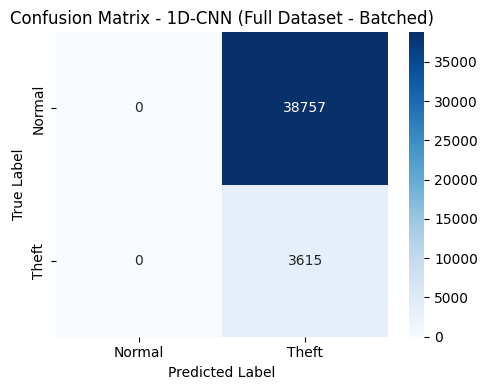

In [29]:
cm_cnn, y_pred_cnn = evaluate_detector_full_dataset_batched(detector, X_scaled, y, device, "1D-CNN",batch_size=256)

In [30]:
detector.to("cpu")
torch.cuda.empty_cache()

In [25]:
class BiLSTM_Detector(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.SELU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (B, L) → (B, L, 1)
        x = x.unsqueeze(-1)
        output, (h_n, c_n) = self.lstm(x)
        # Use last hidden state (or mean pooling)
        features = torch.cat([h_n[-2], h_n[-1]], dim=1)  # concat forward & backward
        return self.fc(features)

In [26]:
# ----------------------------
# Train and evaluate BiLSTM
# ----------------------------
bilstm = BiLSTM_Detector(input_dim=X_balanced.shape[1]).to(device)

epochs_bilstm = 1000

bilstm_optimizer = optim.NAdam(bilstm.parameters(), lr=0.00005)
criterion = nn.BCELoss()

In [27]:
for epoch in tqdm(range(epochs_bilstm), desc="BiLSTM Detector Training"):
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        pred = bilstm(x)
        loss = criterion(pred, y)
        bilstm_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bilstm.parameters(), max_norm=1.0)
        bilstm_optimizer.step()
    if epoch % 20 == 0:
        print(f"BiLSTM Epoch {epoch}: Loss={loss.item():.4f}")

BiLSTM Detector Training:   0%|          | 1/1000 [00:07<1:56:42,  7.01s/it]

BiLSTM Epoch 0: Loss=0.6940


BiLSTM Detector Training:   2%|▏         | 21/1000 [02:20<1:48:45,  6.67s/it]

BiLSTM Epoch 20: Loss=0.6929


BiLSTM Detector Training:   4%|▍         | 41/1000 [04:33<1:47:34,  6.73s/it]

...

BiLSTM Detector Training:  96%|█████████▌| 961/1000 [1:49:08<04:23,  6.76s/it]

BiLSTM Epoch 960: Loss=0.0008


BiLSTM Detector Training:  98%|█████████▊| 981/1000 [1:51:23<02:08,  6.76s/it]

BiLSTM Epoch 980: Loss=0.0009


BiLSTM Detector Training: 100%|██████████| 1000/1000 [1:53:31<00:00,  6.81s/it]


In [28]:
# Define a path to save the Detector
bilstm_detector_save_path = "saved_models/bilstm_detector.pth"
os.makedirs(os.path.dirname(bilstm_detector_save_path), exist_ok=True)

# Save the Detector state
torch.save({
    'model_state_dict': bilstm.state_dict(),
    'optimizer_state_dict': bilstm_optimizer.state_dict(),
    'epoch': epoch,
}, bilstm_detector_save_path)

print(f"Detector saved to {bilstm_detector_save_path}")

Detector saved to saved_models/bilstm_detector.pth


In [27]:
# Load the saved BiLSTM Detector model
bilstm_detector_load_path = "saved_models/bilstm_detector.pth"
checkpoint = torch.load(bilstm_detector_load_path, map_location=device)

bilstm = BiLSTM_Detector(input_dim).to(device)
bilstm.load_state_dict(checkpoint['model_state_dict'])
bilstm.eval()

print(f"BiLSTM Detector loaded from {bilstm_detector_load_path}")

BiLSTM Detector loaded from saved_models/bilstm_detector.pth


Starting evaluation for BiLSTM on 42372 samples in 166 batches...
  Processed batch 50/166
  Processed batch 100/166
  Processed batch 150/166

--- Results for BiLSTM (Evaluated on Full Preprocessed Dataset - Batched) ---
Accuracy: 0.9981
Precision (PPV): 0.9992
Recall (TPR): 0.9790
F1-Score: 0.9890
Confusion Matrix:
[[38754     3]
 [   76  3539]]


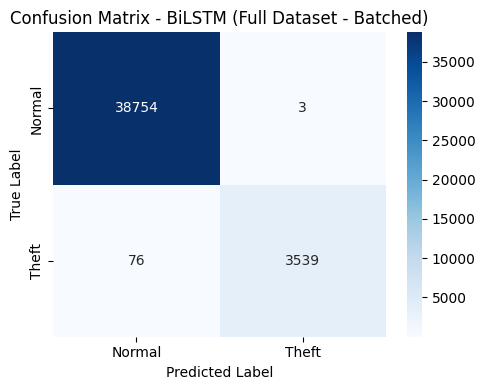

In [31]:
cm_bilstm, y_pred_bilstm = evaluate_detector_full_dataset_batched(bilstm, X_scaled, y, device, "BiLSTM",batch_size=256)

In [32]:
bilstm.to("cpu")
torch.cuda.empty_cache()

In [ ]:
class Transformer_Detector(nn.Module):
    def __init__(self, seq_len, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(1, d_model)
        self.pos_encoding = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=128, batch_first=True, dropout=0.2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.dropout = nn.Dropout(0.2)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.unsqueeze(-1)  # (B, L, 1)
        x = self.embedding(x) + self.pos_encoding
        x = self.transformer(x)
        x = self.dropout(x)
        x = x.transpose(1, 2)  # (B, d_model, L)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

In [ ]:
# ----------------------------
# 3. Train and evaluate Transformer
# ----------------------------
transformer = Transformer_Detector(seq_len=X_balanced.shape[1]).to(device)
transformer_optimizer = optim.AdamW(transformer.parameters(), lr=0.0002)
criterion = nn.BCELoss()
epochs_trans = 1000

In [ ]:
for epoch in tqdm(range(epochs_trans), desc="Transformer Detector Training"):
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        pred = transformer(x)
        loss = criterion(pred, y)
        transformer_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer.parameters(), max_norm=1.0)
        transformer_optimizer.step()
    if epoch % 20 == 0:
        print(f"Transformer Epoch {epoch}: Loss={loss.item():.4f}")

Transformer Detector Training:   0%|          | 1/1000 [01:58<32:56:53, 118.73s/it]

Transformer Epoch 0: Loss=0.0036


Transformer Detector Training:   2%|▏         | 21/1000 [41:14<32:07:18, 118.12s/it]

Transformer Epoch 20: Loss=0.0011


Transformer Detector Training:   4%|▍         | 41/1000 [1:20:37<31:29:06, 118.19s/it]

...

Transformer Detector Training:  96%|█████████▌| 961/1000 [31:26:03<1:16:20, 117.44s/it]

Transformer Epoch 960: Loss=0.0015


Transformer Detector Training:  98%|█████████▊| 981/1000 [32:05:27<37:27, 118.28s/it]

Transformer Epoch 980: Loss=0.0012


Transformer Detector Training: 100%|██████████| 1000/1000 [32:42:54<00:00, 117.77s/it]


In [30]:
# Define a path to save the Detector
transformer_detector_save_path = "saved_models/transformer_detector.pth"
os.makedirs(os.path.dirname(transformer_detector_save_path), exist_ok=True)

# Save the Detector state
torch.save({
    'model_state_dict': transformer.state_dict(),
    'optimizer_state_dict': transformer_optimizer.state_dict(),
    'epoch': epoch,
}, transformer_detector_save_path)

print(f"Detector saved to {transformer_detector_save_path}")

Detector saved to saved_models/transformer_detector.pth


In [35]:
# Load the saved Transformer Detector model
transformer_detector_load_path = "saved_models/transformer_detector.pth"
checkpoint = torch.load(transformer_detector_load_path, map_location=device)

transformer = Transformer_Detector(seq_len=input_dim).to(device)
transformer.load_state_dict(checkpoint['model_state_dict'])
transformer.eval()

print(f"Transformer Detector loaded from {transformer_detector_load_path}")

Transformer Detector loaded from saved_models/transformer_detector.pth


Starting evaluation for Transformer on 42372 samples in 166 batches...
  Processed batch 50/166
  Processed batch 100/166
  Processed batch 150/166

--- Results for Transformer (Evaluated on Full Preprocessed Dataset - Batched) ---
Accuracy: 0.0855
Precision (PPV): 0.0853
Recall (TPR): 0.9997
F1-Score: 0.1572
Confusion Matrix:
[[    8 38749]
 [    1  3614]]


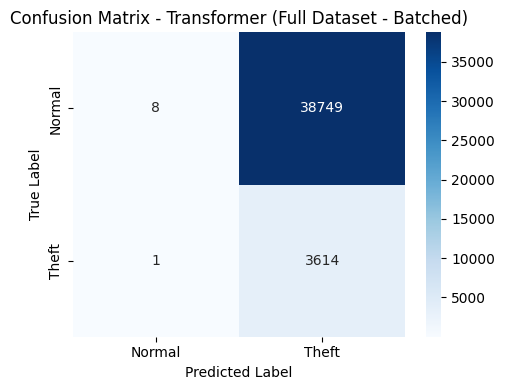

In [36]:
cm_trans, y_pred_trans = evaluate_detector_full_dataset_batched(transformer, X_scaled, y, device, "Transformer",batch_size=256)

In [ ]:
# Inspect Transformer outputs in batches after training
batch_size = 256
num_samples = X_scaled.shape[0]
num_batches = (num_samples + batch_size - 1) // batch_size
outputs_list = []
with torch.no_grad():
    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, num_samples)
        X_batch = X_scaled[start_idx:end_idx]
        X_batch_tensor = torch.from_numpy(X_batch).float().to(device)
        batch_outputs = transformer(X_batch_tensor)
        outputs_list.append(batch_outputs.cpu().numpy().flatten())
outputs_all = np.concatenate(outputs_list, axis=0)
print("Transformer outputs (first 100):", outputs_all[:100])
print("Min output:", outputs_all.min(), "Max output:", outputs_all.max())

In [32]:
transformer.to("cpu")
torch.cuda.empty_cache()